In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

import seaborn as sns

def custom_grouping(index):
    return index // 1000

names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
names_latency=['time', 'latency', 'op2', 'write_size', 'op3']

In [2]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/90Util/run1/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

In [3]:
# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576 #1MB
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]

/var/folders/2k/prv9ywh52sn57l626bl42pz40000gp/T/ipykernel_71547/3920337363.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[8439.86634668 8439.86634668 8439.86634668 8439.86634668 8439.86634668
 8439.86634668 8439.86634668 8439.86634668 8439.86634668 8439.86634668
 8439.86634668 8439.86634668 8439.86634668 8439.86634668 8439.86634668
 8439.86634668 8439.86634668 8439.86634668 8439.86634668 8439.86634668
 8439.86634668 8439.86634668 8439.86634668 8439.86634668 8439.86634668
 8439.86634668 8439.86634668 8439.86634668 8439.86634668 8439.86634668
 8439.86634668 8439.86634668 8439.86634668 8439.86634668 8439.86634668
 8439.86634668 8439.86634668 8439.86634668 8439.86634668 8439.86634668
 8439.86634668 8439.86634668 8439.86634668 8439.86634668 8439.86634668
 8439.86634668 8439.86634668 8439.86634668 8439.86634668 8439.86634668
 8439.86634668 8439.86634668 8439.86634668 8439.86634668 8439.86634668
 8439.8

46079


In [4]:
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped.describe())
print(df_grouped.info())

             index  data_written_bytes  cumulative_gb
count  5872.000000         5872.000000    5872.000000
mean   2935.500000            7.847411      40.043651
std    1695.244722           29.648598       5.758968
min       0.000000            0.000234       0.093369
25%    1467.750000            1.175768      38.421735
50%    2935.500000            1.556252      40.762818
75%    4403.250000            2.110963      43.294814
max    5871.000000          168.485531      45.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5872 entries, 0 to 5871
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               5872 non-null   int64  
 1   data_written_bytes  5872 non-null   float64
 2   cumulative_gb       5872 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 137.8 KB
None


In [5]:
data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + ' MB/s'
avg_bw_str2 = str(round(average_mode2, 2)) + ' MB/s'

Average1: 2
Average2: 147


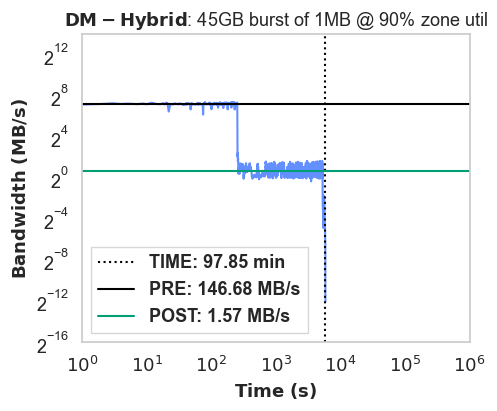

In [10]:
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped, color='#648FFF')
plt.title(r"$\bf{DM-Hybrid}$: 45GB burst of 1MB @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='#009E73', linestyle='-', label='POST: ' + avg_bw_str1)
plt.legend(loc='lower left', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
           shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13 )

plt.savefig('figs/1M_90Util_DMHybrid_BW.pdf', bbox_inches='tight',dpi=500)
plt.show()

## DM-Hybrid 5GB burst of 4KB @ 90% zone util

In [11]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('fast2026/STL/4K/90-10-LBA/90Util/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

In [12]:
# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = math.ceil(df['completion_time'].max())
print("End time: " + str(int(end_time)))


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)

    payload = 4096  # 4KB
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]

End time: 114826928


/var/folders/2k/prv9ywh52sn57l626bl42pz40000gp/T/ipykernel_19797/3304125787.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[446.56957485 446.56957485 446.56957485 446.56957485 446.56957485
 446.56957485 446.56957485 446.56957485 446.56957485]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_written_ms.loc[start:end-1] += write_rate_per_ms


KeyboardInterrupt: 

In [29]:
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped.describe())
print(df_grouped.info())

               index  data_written_bytes  cumulative_gb
count  114827.000000       114827.000000  114827.000000
mean    57413.000000            0.044589       3.962948
std     33147.844017            0.509212       0.842747
min         0.000000            0.000000       0.006386
25%     28706.500000            0.004815       3.216151
50%     57413.000000            0.007402       3.993062
75%     86119.500000            0.009973       4.871017
max    114826.000000           14.662164       5.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114827 entries, 0 to 114826
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               114827 non-null  int64  
 1   data_written_bytes  114827 non-null  float64
 2   cumulative_gb       114827 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 2.6 MB
None


In [30]:
data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + ' MB/s'
avg_bw_str2 = str(round(average_mode2, 2)) + ' MB/s'

Average1: 0
Average2: 11


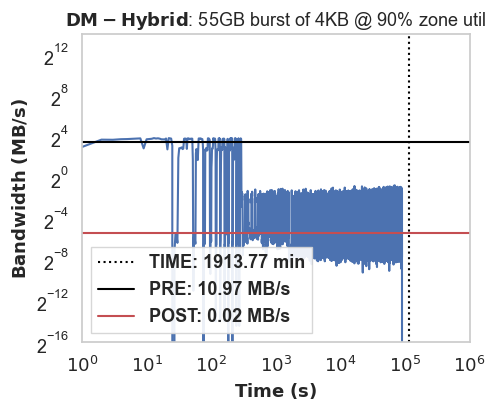

In [31]:
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped)
plt.title(r"$\bf{DM-Hybrid}$: 55GB burst of 4KB @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='POST: ' + avg_bw_str1)
plt.legend(loc='lower left', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
           shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13 )

plt.savefig('figs/4K_90Util_DMHybrid_BW.pdf', bbox_inches='tight',dpi=500)
plt.show()

Comparison of both approaches:
False
False
DataFrames are equal: False
DataFrames are equal: False
               index  data_written_bytes  cumulative_gb
count  114827.000000       114827.000000  114827.000000
mean    57413.000000            0.044589       3.962948
std     33147.844017            0.509212       0.842747
min         0.000000            0.000000       0.006386
25%     28706.500000            0.004815       3.216151
50%     57413.000000            0.007402       3.993062
75%     86119.500000            0.009973       4.871017
max    114826.000000           14.662164       5.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114827 entries, 0 to 114826
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               114827 non-null  int64  
 1   data_written_bytes  114827 non-null  float64
 2   cumulative_gb       114827 non-null  float64
dtypes: float64(2), int64(1)
memory u

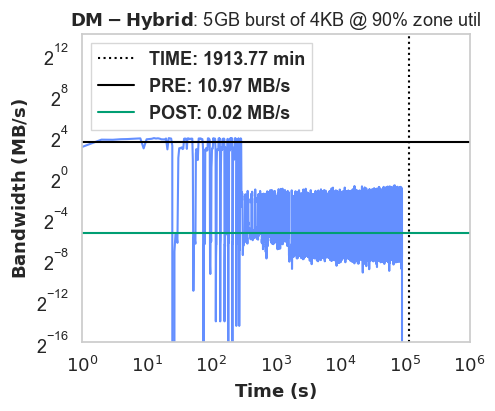

In [14]:
"""Vectorized approach - fastest for most datasets"""

# Step 3: Determine time range
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Pre-compute all values vectorized
df_vec = df.copy()
df_vec['duration'] = df_vec['duration'].astype(float)
df_vec['start'] = df_vec['submission_time'].astype(int)
df_vec['end'] = df_vec['start'] + np.floor(df_vec['duration']).astype(int)

payload = 4096  # 4KB
df_vec['write_rate_per_ms'] = payload / np.maximum(df_vec['duration'], 1.0)
df_vec['floor_duration'] = np.floor(df_vec['duration']).astype(int)
df_vec['residue'] = payload - df_vec['write_rate_per_ms'] * df_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)

#Compare both approaches
print("Comparison of both approaches:")
print(data_written_ms.equals(data_written_ms_vec))  # Should return True if both methods yield the same result
print(data_written_ms_vec.equals(data_written_ms))  # Should return True if both methods yield the same result

#check if the dataframes are equal
print("DataFrames are equal:", data_written_ms.equals(data_written_ms_vec))  # Should return True if both methods yield the same result
print("DataFrames are equal:", data_written_ms_vec.equals(data_written_ms))  # Should return True if both methods yield the same result

##################################

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_grouped_vec.reset_index(inplace=True)
df_grouped_vec['cumulative_gb'] = df_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped_vec['data_written_bytes'] = df_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped_vec.describe())
print(df_grouped_vec.info())

####################

data_array_vec = df_grouped_vec['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array_vec)
# Get the cluster centers
cluster_centers_vec = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers_vec.sort()
# Calculate the average of each mode
average_mode1_vec = cluster_centers_vec[0]
average_mode2_vec = cluster_centers_vec[1]
print("Average1: " + str(round(average_mode1_vec, )))
print("Average2: " + str(round(average_mode2_vec, )))
avg_bw_str1 = str(round(average_mode1_vec, 2)) + ' MB/s'
avg_bw_str2 = str(round(average_mode2_vec, 2)) + ' MB/s'

####################
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped_vec, color= "#648FFF")
plt.title(r"$\bf{DM-Hybrid}$: 5GB burst of 4KB @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped_vec.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=average_mode2_vec, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1_vec, color='#009E73', linestyle='-', label='POST: ' + avg_bw_str1)
plt.legend(loc='upper left', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
           shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13 )

plt.savefig('figs/4K_90Util_DMHybrid_BW.pdf', bbox_inches='tight',dpi=500)
plt.show()

In [27]:
"""Vectorized approach - fastest for most datasets"""

# Step 3: Determine time range
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Pre-compute all values vectorized
df_vec = df.copy()
df_vec['duration'] = df_vec['duration'].astype(float)
df_vec['start'] = df_vec['submission_time'].astype(int)
df_vec['end'] = df_vec['start'] + np.floor(df_vec['duration']).astype(int)

payload = 4096  # 4KB
df_vec['write_rate_per_ms'] = payload / np.maximum(df_vec['duration'], 1.0)
df_vec['floor_duration'] = np.floor(df_vec['duration']).astype(int)
df_vec['residue'] = payload - df_vec['write_rate_per_ms'] * df_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)

# #Compare both approaches
# print("Comparison of both approaches:")
# print(data_written_ms.equals(data_written_ms_vec))  # Should return True if both methods yield the same result
# print(data_written_ms_vec.equals(data_written_ms))  # Should return True if both methods yield the same result

# #check if the dataframes are equal
# print("DataFrames are equal:", data_written_ms.equals(data_written_ms_vec))  # Should return True if both methods yield the same result
# print("DataFrames are equal:", data_written_ms_vec.equals(data_written_ms))  # Should return True if both methods yield the same result

##################################

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_grouped_vec.reset_index(inplace=True)
df_grouped_vec['cumulative_gb'] = df_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped_vec['data_written_bytes'] = df_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped_vec.describe())
print(df_grouped_vec.info())

####################

data_array_vec = df_grouped_vec['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array_vec)
# Get the cluster centers
cluster_centers_vec = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers_vec.sort()
# Calculate the average of each mode
average_mode1_vec = cluster_centers_vec[0]
average_mode2_vec = cluster_centers_vec[1]
print("Average1: " + str(round(average_mode1_vec, )))
print("Average2: " + str(round(average_mode2_vec, )))
avg_bw_str1 = str(round(average_mode1_vec, 2)) + ' MB/s'
avg_bw_str2 = str(round(average_mode2_vec, 2)) + ' MB/s'

             index  data_written_bytes  cumulative_gb
count  4452.000000         4452.000000    4452.000000
mean   2225.500000            0.183741       0.744201
std    1285.326029            1.175152       0.067563
min       0.000000            0.000000       0.004653
25%    1112.750000            0.023202       0.723819
50%    2225.500000            0.025102       0.750821
75%    3338.250000            0.026414       0.777465
max    4451.000000            9.456908       0.798843
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4452 entries, 0 to 4451
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               4452 non-null   int64  
 1   data_written_bytes  4452 non-null   float64
 2   cumulative_gb       4452 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 104.5 KB
None
Average1: 0
Average2: 9


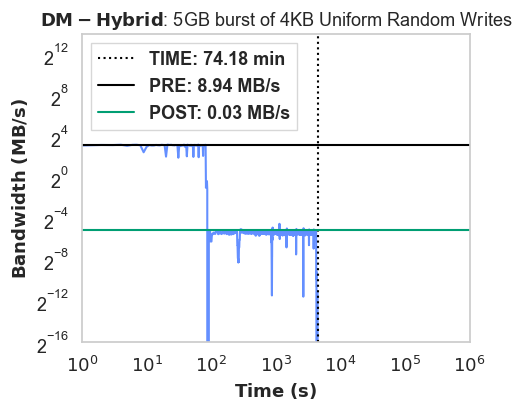

In [28]:
####################
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped_vec, color= "#648FFF")
plt.title(r"$\bf{DM-Hybrid}$: 5GB burst of 4KB Uniform Random Writes", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped_vec.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=average_mode2_vec, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1_vec, color='#009E73', linestyle='-', label='POST: ' + avg_bw_str1)
plt.legend(loc='upper left', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
           shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13 )

plt.savefig('figs/4K_Uniform_DMHybrid_BW.pdf', bbox_inches='tight',dpi=500)
plt.show()

## DM-Hybrid 45GB burst of 1MB @ 90% zone util

In [29]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('fast2026/STL/1M/uniform/90Util/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

/var/folders/2k/prv9ywh52sn57l626bl42pz40000gp/T/ipykernel_93797/1666430685.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[5019.14589988 5019.14589988 5019.14589988 5019.14589988 5019.14589988
 5019.14589988 5019.14589988 5019.14589988 5019.14589988 5019.14589988
 5019.14589988 5019.14589988 5019.14589988 5019.14589988 5019.14589988
 5019.14589988 5019.14589988 5019.14589988 5019.14589988 5019.14589988
 5019.14589988 5019.14589988 5019.14589988 5019.14589988 5019.14589988
 5019.14589988 5019.14589988 5019.14589988 5019.14589988 5019.14589988
 5019.14589988 5019.14589988 5019.14589988 5019.14589988 5019.14589988
 5019.14589988 5019.14589988 5019.14589988 5019.14589988 5019.14589988
 5019.14589988 5019.14589988 5019.14589988 5019.14589988 5019.14589988
 5019.14589988 5019.14589988 5019.14589988 5019.14589988 5019.14589988
 5019.14589988 5019.14589988 5019.14589988 5019.14589988 5019.14589988
 5019.1

46079
Min Idx: 
1053
Average1: 4
Average2: 116


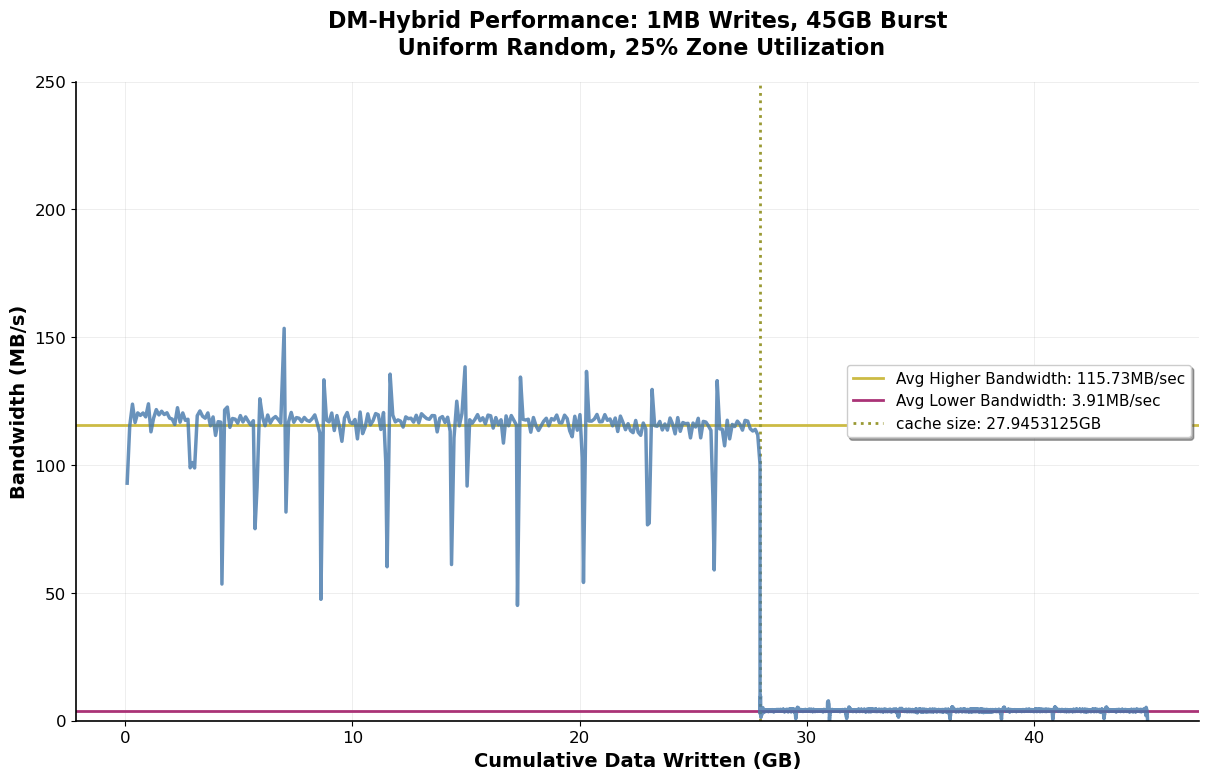

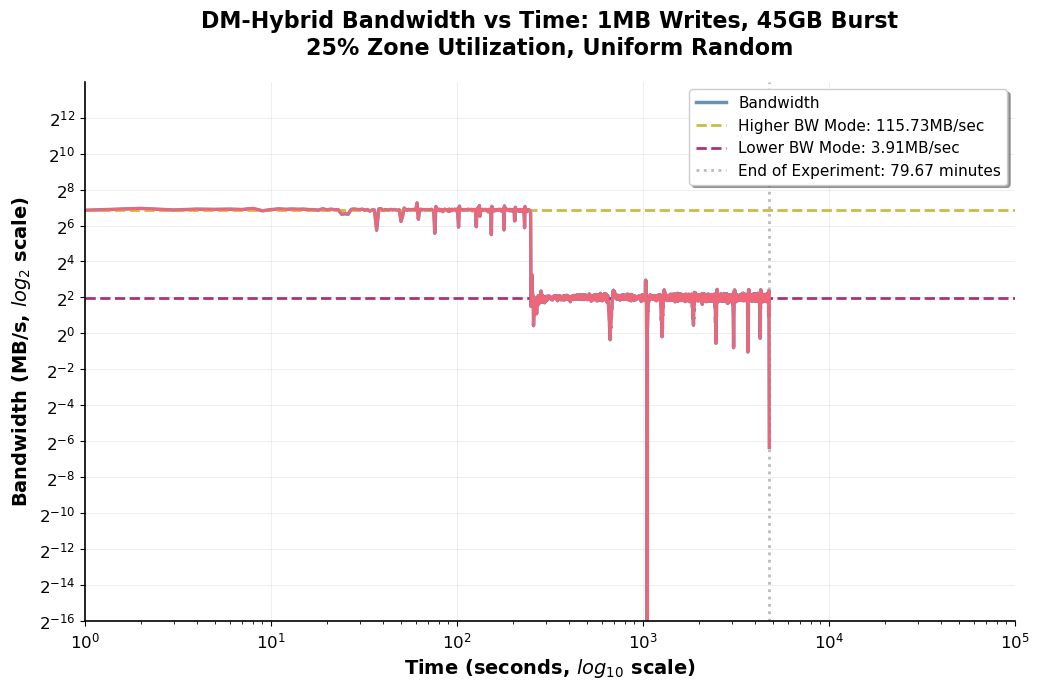

4780


In [30]:
# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = (1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 

# Filter the DataFrame for rows where 'data_written_bytes' is less than 75
filtered_df = df_grouped[df_grouped['data_written_bytes'] < 20]
# Get the corresponding 'cumulative_gb' values
cumulative_gb_values = filtered_df['cumulative_gb']
# If you want the first occurrence where 'data_written_bytes' is less than 75
first_cumulative_gb = cumulative_gb_values.iloc[0] if not cumulative_gb_values.empty else 45


#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
COLORS = {
    'plot1': '#4477AA',  # Blue
    'plot2': '#EE6677',  # Red  
    'plot3': '#228833',  # Green
    'high_bw': '#CCBB44',  # Yellow
    'low_bw': '#AA3377',   # Purple
    'cache': '#999933',    # Olive
    'end_exp': '#BBBBBB'   # Gray
}

# Set up the plotting style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.figsize': (10, 6),
    'figure.dpi': 100,
    'lines.linewidth': 2,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 1.2,
})

fig, ax = plt.subplots(figsize=(12, 7))

ax.axhline(y=average_mode2, color=COLORS['high_bw'], linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
ax.axhline(y=average_mode1, color=COLORS['low_bw'], linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
ax.axvline(x=first_cumulative_gb, color=COLORS['cache'], linestyle=':', label="cache size: " + str(round(first_cumulative_gb, 10)) + "GB")
# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

ax.legend(loc='center right', frameon=True, fancybox=True, shadow=True)
# Plot the data size over time for each resolution
plt.tight_layout()
ax.set_ylim(0 , 250)
plot_color = "plot1"
ax.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'], color=COLORS[plot_color], linewidth=2.5, alpha=0.8, label='CGBW')
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
ax.set_xlabel('Cumulative Data Written (GB)', fontweight='bold')
ax.set_ylabel('Bandwidth (MB/s)', fontweight='bold')
# Grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_title('DM-Hybrid Performance: 1MB Writes, 45GB Burst\n Uniform Random, 25% Zone Utilization', 
                 fontweight='bold', pad=20)

plt.savefig('figs/1M_Uniform_25Util_DMHybrid_CGBW.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


fig, ax = plt.subplots(figsize=(12, 7))
plot_color = 'plot1'
ax.plot(df_grouped.index, df_grouped['data_written_bytes'], color=COLORS[plot_color], linewidth=2.5, alpha=0.8, label='Bandwidth')
ax.axhline(y=average_mode2, color=COLORS['high_bw'], linestyle='--', linewidth=2, label=f'Higher BW Mode: {avg_bw_str2}')
ax.axhline(y=average_mode1, color=COLORS['low_bw'], linestyle='--', linewidth=2, label=f'Lower BW Mode: {avg_bw_str1}')
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])


# End of experiment line
xmax = df_grouped.index.max()
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color=COLORS['end_exp'], linestyle=':', linewidth=2, label=f'End of Experiment: {xmin} minutes')
    
    # Log scales
ax.set_xscale('log', base=10)
ax.set_yscale('log', base=2)


ax.set_xlabel('Time (seconds, $log_{10}$ scale)', fontweight='bold')
ax.set_ylabel('Bandwidth (MB/s, $log_2$ scale)', fontweight='bold')
ax.set_title('DM-Hybrid Bandwidth vs Time: 1MB Writes, 45GB Burst\n25% Zone Utilization, Uniform Random', fontweight='bold', pad=20)
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)


common_yticks = [2**i for i in range(-16, 14, 2)]
common_xticks = [10**i for i in range(0, 6)]
ax.set_yticks(common_yticks)
ax.set_xticks(common_xticks)


# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'


ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_ylim(lowest_power_of_2 , 2**14)

ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_xticks)

plot_color = 'plot2'
ax.plot(df_grouped.index, df_grouped['data_written_bytes'], color=COLORS[plot_color], label="Bandwidth")
ax.set_title('DM-Hybrid Bandwidth vs Time: 1MB Writes, 45GB Burst\n25% Zone Utilization, Uniform Random', fontweight='bold', pad=20)
plt.savefig('figs/1M_Uniform_DMHybrid_BW.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(str(df_grouped.index[-1]))

/var/folders/2k/prv9ywh52sn57l626bl42pz40000gp/T/ipykernel_93797/2335073123.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[846.43051613 846.43051613 846.43051613 846.43051613]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_written_ms.loc[start:end-1] += write_rate_per_ms


209411
Min Idx: 
88
Average1: 0
Average2: 9


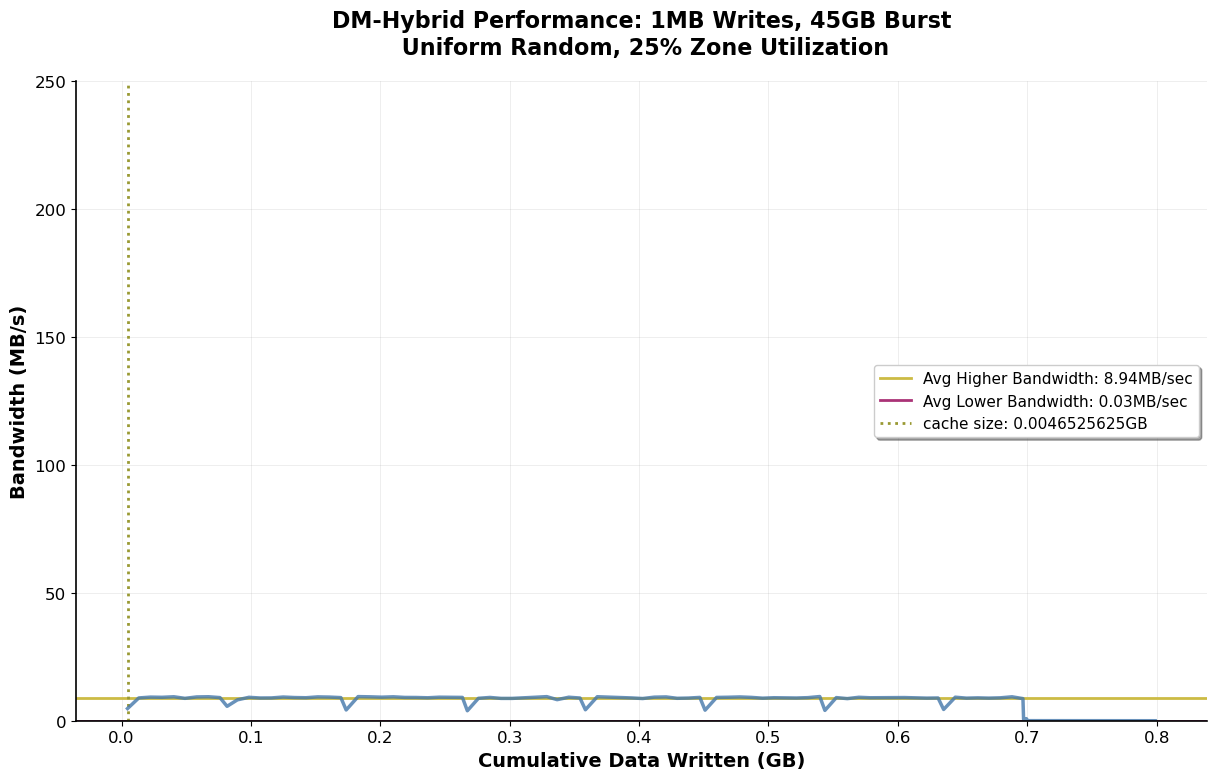

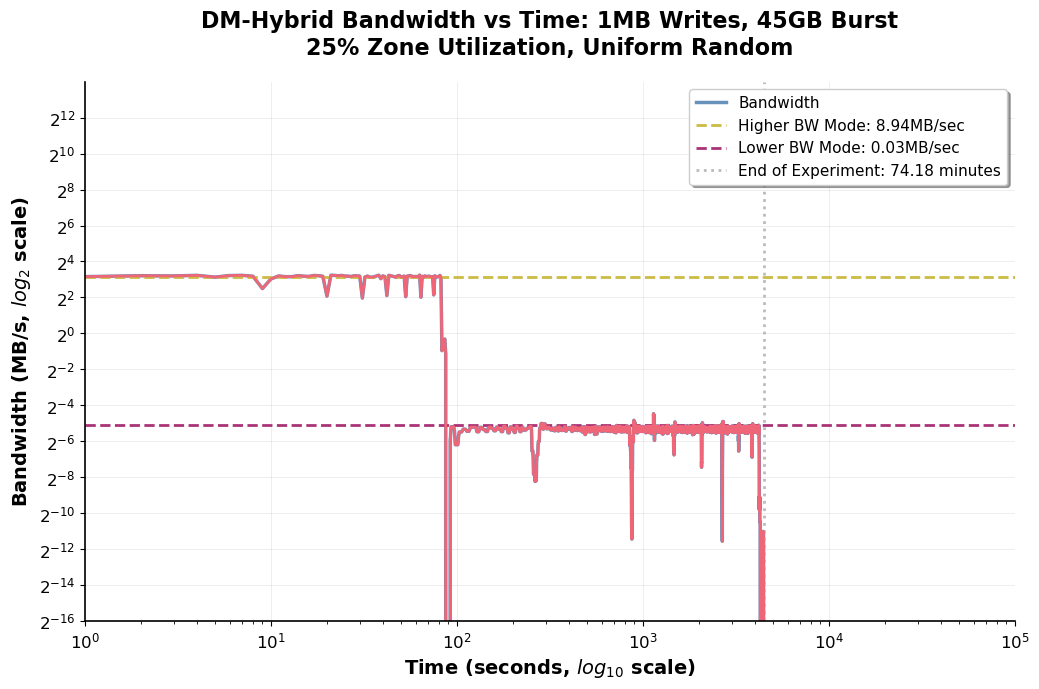

4451


In [33]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
# df = pd.read_csv('fast2026/STL/1M/uniform/90Util/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df = pd.read_csv('fast2026/STL/4K/uniform/sda/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']


# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 4096 #(1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 

# Filter the DataFrame for rows where 'data_written_bytes' is less than 75
filtered_df = df_grouped[df_grouped['data_written_bytes'] < 20]
# Get the corresponding 'cumulative_gb' values
cumulative_gb_values = filtered_df['cumulative_gb']
# If you want the first occurrence where 'data_written_bytes' is less than 75
first_cumulative_gb = cumulative_gb_values.iloc[0] if not cumulative_gb_values.empty else 45


#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
COLORS = {
    'plot1': '#4477AA',  # Blue
    'plot2': '#EE6677',  # Red  
    'plot3': '#228833',  # Green
    'high_bw': '#CCBB44',  # Yellow
    'low_bw': '#AA3377',   # Purple
    'cache': '#999933',    # Olive
    'end_exp': '#BBBBBB'   # Gray
}

# Set up the plotting style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.figsize': (10, 6),
    'figure.dpi': 100,
    'lines.linewidth': 2,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 1.2,
})

fig, ax = plt.subplots(figsize=(12, 7))

ax.axhline(y=average_mode2, color=COLORS['high_bw'], linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
ax.axhline(y=average_mode1, color=COLORS['low_bw'], linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
ax.axvline(x=first_cumulative_gb, color=COLORS['cache'], linestyle=':', label="cache size: " + str(round(first_cumulative_gb, 10)) + "GB")
# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

ax.legend(loc='center right', frameon=True, fancybox=True, shadow=True)
# Plot the data size over time for each resolution
plt.tight_layout()
ax.set_ylim(0 , 250)
plot_color = "plot1"
ax.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'], color=COLORS[plot_color], linewidth=2.5, alpha=0.8, label='CGBW')
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
ax.set_xlabel('Cumulative Data Written (GB)', fontweight='bold')
ax.set_ylabel('Bandwidth (MB/s)', fontweight='bold')
# Grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_title('DM-Hybrid Performance: 1MB Writes, 45GB Burst\n Uniform Random, 25% Zone Utilization', 
                 fontweight='bold', pad=20)

plt.savefig('figs/1M_Uniform_25Util_DMHybrid_CGBW.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


fig, ax = plt.subplots(figsize=(12, 7))
plot_color = 'plot1'
ax.plot(df_grouped.index, df_grouped['data_written_bytes'], color=COLORS[plot_color], linewidth=2.5, alpha=0.8, label='Bandwidth')
ax.axhline(y=average_mode2, color=COLORS['high_bw'], linestyle='--', linewidth=2, label=f'Higher BW Mode: {avg_bw_str2}')
ax.axhline(y=average_mode1, color=COLORS['low_bw'], linestyle='--', linewidth=2, label=f'Lower BW Mode: {avg_bw_str1}')
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])


# End of experiment line
xmax = df_grouped.index.max()
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color=COLORS['end_exp'], linestyle=':', linewidth=2, label=f'End of Experiment: {xmin} minutes')
    
    # Log scales
ax.set_xscale('log', base=10)
ax.set_yscale('log', base=2)


ax.set_xlabel('Time (seconds, $log_{10}$ scale)', fontweight='bold')
ax.set_ylabel('Bandwidth (MB/s, $log_2$ scale)', fontweight='bold')
ax.set_title('DM-Hybrid Bandwidth vs Time: 1MB Writes, 45GB Burst\n25% Zone Utilization, Uniform Random', fontweight='bold', pad=20)
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)


common_yticks = [2**i for i in range(-16, 14, 2)]
common_xticks = [10**i for i in range(0, 6)]
ax.set_yticks(common_yticks)
ax.set_xticks(common_xticks)


# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'


ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_ylim(lowest_power_of_2 , 2**14)

ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_xticks)

plot_color = 'plot2'
ax.plot(df_grouped.index, df_grouped['data_written_bytes'], color=COLORS[plot_color], label="Bandwidth")
ax.set_title('DM-Hybrid Bandwidth vs Time: 1MB Writes, 45GB Burst\n25% Zone Utilization, Uniform Random', fontweight='bold', pad=20)
plt.savefig('figs/1M_Uniform_DMHybrid_BW.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(str(df_grouped.index[-1]))